In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

In [16]:
df = pd.read_csv('student_performance_dataset_req.csv')

df.fillna(df.mean(numeric_only=True), inplace=True)

if 'Final_Result' in df.columns:
    df['Final_Result'] = df['Final_Result'].map({'Pass': 1, 'Fail': 0})

df.head()

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Final_Result
0,1,6,55,57,76,56,0
1,2,9,55,58,97,76,0
2,3,3,55,69,44,89,0
3,4,6,60,63,88,54,1
4,5,7,71,55,54,80,1


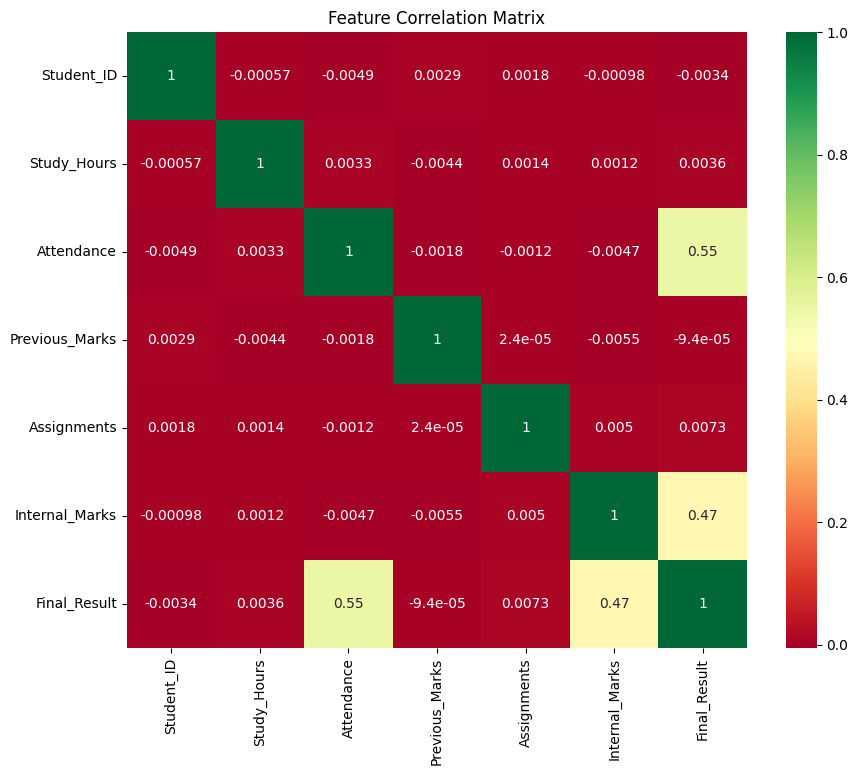

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn')
plt.title('Feature Correlation Matrix')
plt.show()

In [18]:
X = df[['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks']]
y = df['Final_Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.8359
Decision Tree Accuracy: 1.0000
Random Forest Accuracy: 1.0000
Naive Bayes Accuracy: 0.9208
SVM Accuracy: 0.9859


Final Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10497
           1       1.00      1.00      1.00      9503

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



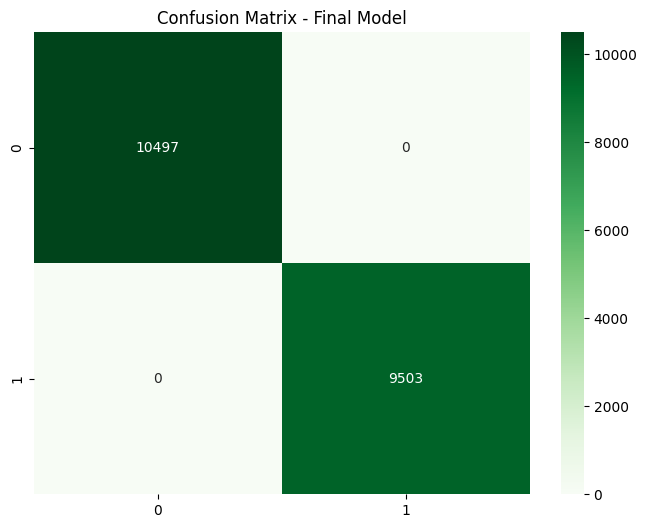

In [19]:
final_model = RandomForestClassifier()
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print("Final Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Final Model')
plt.show()

In [20]:
test_data_with_results = X_test.copy()
test_data_with_results['Predicted_Status'] = y_pred

at_risk = test_data_with_results[test_data_with_results['Predicted_Status'] == 0]
print("List of Students at Risk of Failing:")
print(at_risk.head(10))

with open('student_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

List of Students at Risk of Failing:
       Study_Hours  Attendance  Previous_Marks  Assignments  Internal_Marks  \
75721            9          94              99           35              40   
80184            7          55              75           43              97   
19864            6          52              65           35              76   
76434            1          89              46           50              44   
60767            6          45              31           69              91   
42141            9          56              98           88              70   
16638            3          42              63           99              34   
88702            7          58              89           88              51   
149              9          47              87           80              79   
1761             4          52              47           34              86   

       Predicted_Status  
75721                 0  
80184                 0  
19864          